
**Phase 1 — EDA + TF-IDF Baseline**

In [7]:
# ── Cell 1: Install & Imports ──────────────────────────────────────────────
!pip install -q scikit-learn pandas numpy matplotlib seaborn wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from scipy.sparse import hstack

print('✅ All imports successful')

✅ All imports successful


In [8]:
# ── Cell 2: Load Data ──────────────────────────────────────────────────────
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

LABELS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
print(f'\nLabel columns: {LABELS}')
train.head(3)

Train shape : (16000, 8)
Test shape  : (4000, 2)

Label columns: ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,cbf2efa71bcb1d1f,"""\n\n Merge \n\nThere is a merge discussion he...",0,0,0,0,0,0
1,a8ef231f2462ae21,Obama's father was muslim this is a proven fac...,0,0,0,0,0,0
2,8b7ddc7d64a596fd,""" I'm a morbidly obese individual, so I know a...",0,0,0,0,0,0


In [9]:
# ── Cell 3: Missing Values & Basic Sanity Check ────────────────────────────
print('=== Missing values ===')
print(train.isnull().sum())

# Fill any NaN comments
train['comment_text'] = train['comment_text'].fillna('unknown')
test['comment_text']  = test['comment_text'].fillna('unknown')

# Comments with NO label at all (clean)
train['clean'] = (train[LABELS].sum(axis=1) == 0).astype(int)
print(f'\nClean comments : {train["clean"].sum():,} ({train["clean"].mean()*100:.1f}%)')

=== Missing values ===
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

Clean comments : 14,375 (89.8%)


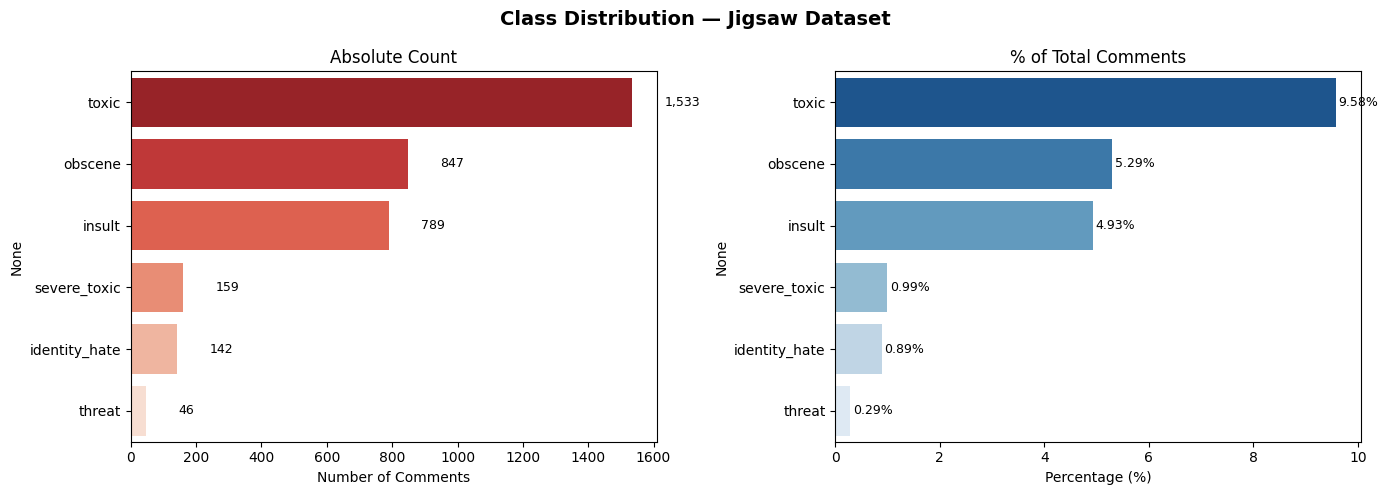


⚠️  Severe class imbalance noted — especially for threat & identity_hate


In [10]:
# ── Cell 4: Class Distribution ─────────────────────────────────────────────
label_counts = train[LABELS].sum().sort_values(ascending=False)
label_pct    = (label_counts / len(train)) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution — Jigsaw Dataset', fontsize=14, fontweight='bold')

# Count
sns.barplot(x=label_counts.values, y=label_counts.index, palette='Reds_r', ax=axes[0])
axes[0].set_title('Absolute Count')
axes[0].set_xlabel('Number of Comments')
for i, v in enumerate(label_counts.values):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

# Percentage
sns.barplot(x=label_pct.values, y=label_pct.index, palette='Blues_r', ax=axes[1])
axes[1].set_title('% of Total Comments')
axes[1].set_xlabel('Percentage (%)')
for i, v in enumerate(label_pct.values):
    axes[1].text(v + 0.05, i, f'{v:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()
print('\n⚠️  Severe class imbalance noted — especially for threat & identity_hate')

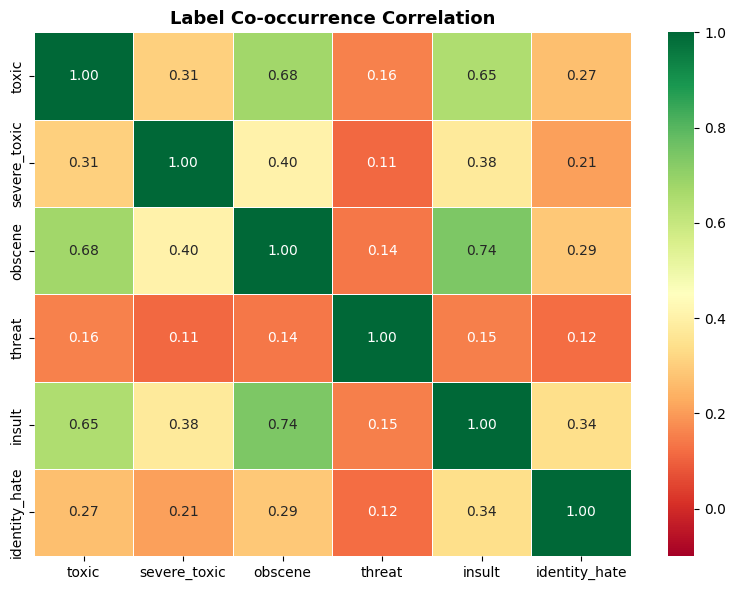


💡 Toxic & obscene/insult are highly correlated — expected.


In [11]:
# ── Cell 5: Label Co-occurrence Heatmap ───────────────────────────────────
corr = train[LABELS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # hide upper triangle

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, mask=False, vmin=-0.1, vmax=1)
plt.title('Label Co-occurrence Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('\n💡 Toxic & obscene/insult are highly correlated — expected.')

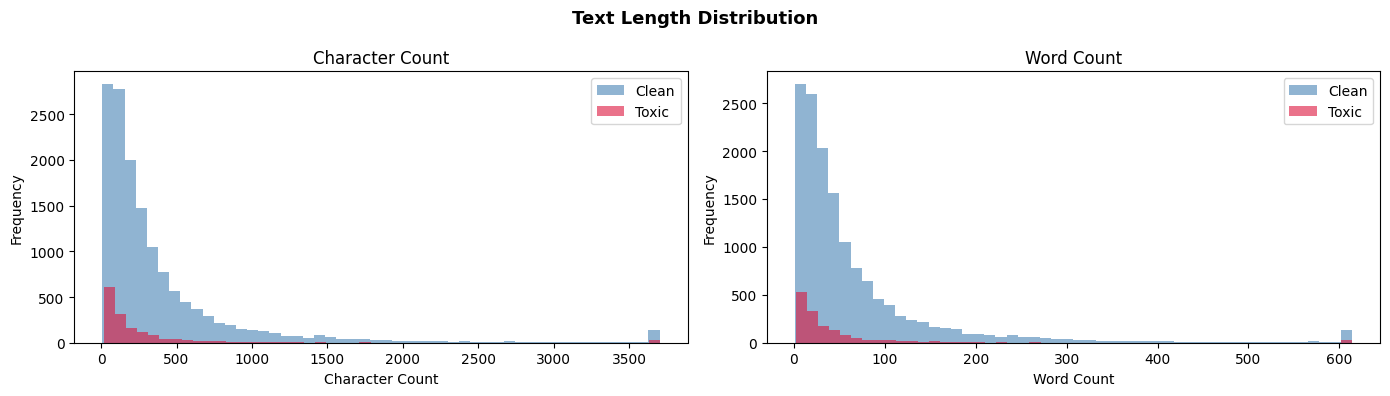

Avg words — Toxic:  55.7
Avg words — Clean:  69.0


In [12]:
# ── Cell 6: Text Length Analysis ──────────────────────────────────────────
train['char_len'] = train['comment_text'].str.len()
train['word_len'] = train['comment_text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Text Length Distribution', fontsize=13, fontweight='bold')

for col, ax, label in zip(['char_len', 'word_len'], axes,
                           ['Character Count', 'Word Count']):
    toxic_mask = train['toxic'] == 1
    ax.hist(train.loc[~toxic_mask, col].clip(upper=train[col].quantile(0.99)),
            bins=50, alpha=0.6, label='Clean', color='steelblue')
    ax.hist(train.loc[toxic_mask, col].clip(upper=train[col].quantile(0.99)),
            bins=50, alpha=0.6, label='Toxic', color='crimson')
    ax.set_xlabel(label); ax.set_ylabel('Frequency')
    ax.legend(); ax.set_title(label)

plt.tight_layout()
plt.show()

print(f"Avg words — Toxic:  {train.loc[train.toxic==1,'word_len'].mean():.1f}")
print(f"Avg words — Clean:  {train.loc[train.toxic==0,'word_len'].mean():.1f}")

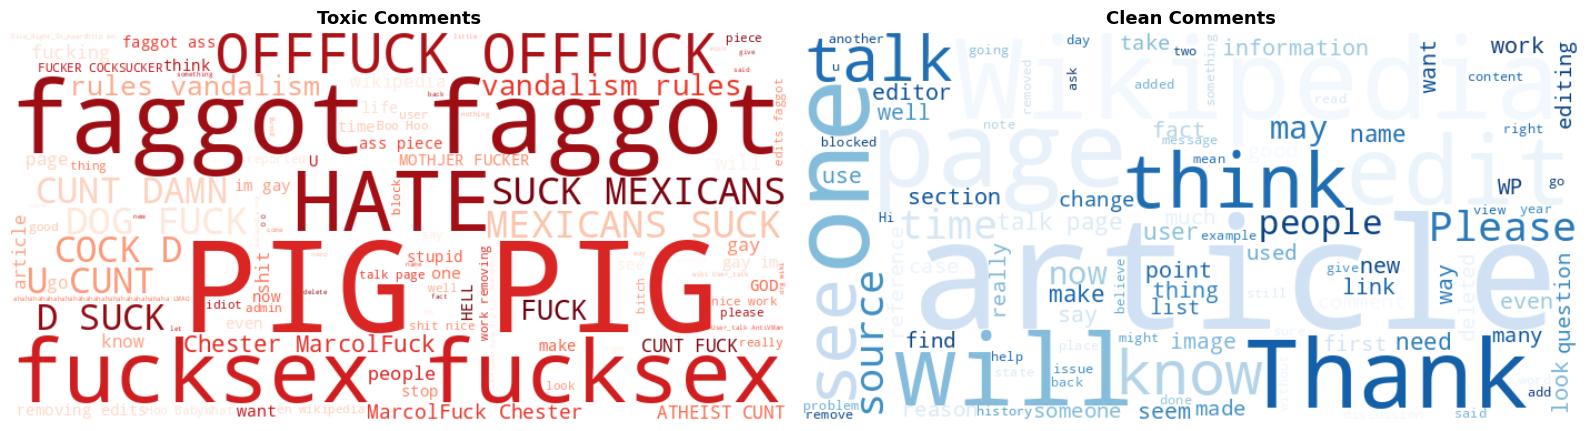

In [13]:
# ── Cell 7: WordClouds ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, mask_val, title, color in zip(
    axes, [1, 0], ['Toxic Comments', 'Clean Comments'], ['Reds', 'Blues']):
    text = ' '.join(train.loc[train['toxic'] == mask_val, 'comment_text'].sample(
        min(3000, (train['toxic']==mask_val).sum()), random_state=42))
    wc = WordCloud(width=700, height=350, background_color='white',
                   colormap=color, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [14]:
# ── Cell 8: Preprocessing ─────────────────────────────────────────────────
import re

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' url ', text)   # URLs
    text = re.sub(r'[^\w\s!?]', ' ', text)                   # keep ! and ?
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train['clean_text'] = train['comment_text'].apply(preprocess)
test['clean_text']  = test['comment_text'].apply(preprocess)

print('Before:', train['comment_text'].iloc[0][:120])
print('After :', train['clean_text'].iloc[0][:120])

Before: "

 Merge 

There is a merge discussion here  talk "
After : merge there is a merge discussion here talk


In [15]:
# ── Cell 9: TF-IDF Vectorizers (Word + Char n-grams) ──────────────────────
# Word-level: captures semantic meaning
word_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=100_000,
    min_df=3,
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'\w{1,}'
)

# Char-level: catches obfuscated toxic words (a$$, st*pid)
char_tfidf = TfidfVectorizer(
    ngram_range=(2, 6),
    max_features=100_000,
    min_df=3,
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='char_wb'
)

X_train_word = word_tfidf.fit_transform(train['clean_text'])
X_train_char = char_tfidf.fit_transform(train['clean_text'])
X_train = hstack([X_train_word, X_train_char])

X_test_word = word_tfidf.transform(test['clean_text'])
X_test_char = char_tfidf.transform(test['clean_text'])
X_test = hstack([X_test_word, X_test_char])

y_train = train[LABELS].values
print(f'Feature matrix shape: {X_train.shape}')
print('✅ TF-IDF features ready')

Feature matrix shape: (16000, 160933)
✅ TF-IDF features ready


In [16]:
# ── Cell 10: Validation Split ─────────────────────────────────────────────
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)
print(f'Train: {X_tr.shape[0]:,} | Val: {X_val.shape[0]:,}')

Train: 14,400 | Val: 1,600


In [17]:
# ── Cell 11: Train Logistic Regression Baseline ───────────────────────────
# One model per label (Binary Relevance)
models = {}
val_preds = np.zeros((X_val.shape[0], len(LABELS)))

for i, label in enumerate(LABELS):
    print(f'Training: {label}...')
    clf = LogisticRegression(
        C=5.0,
        solver='sag',
        max_iter=1000,
        class_weight='balanced'   # handles class imbalance!
    )
    clf.fit(X_tr, y_tr[:, i])
    models[label] = clf
    val_preds[:, i] = clf.predict_proba(X_val)[:, 1]

print('\n✅ Training complete!')

Training: toxic...
Training: severe_toxic...
Training: obscene...
Training: threat...
Training: insult...
Training: identity_hate...

✅ Training complete!


In [18]:
# ── Cell 12: Evaluation — ROC-AUC & F1 ────────────────────────────────────
results = []
for i, label in enumerate(LABELS):
    auc = roc_auc_score(y_val[:, i], val_preds[:, i])
    preds_bin = (val_preds[:, i] >= 0.5).astype(int)
    f1  = f1_score(y_val[:, i], preds_bin, zero_division=0)
    results.append({'Label': label, 'ROC-AUC': round(auc, 4), 'F1': round(f1, 4)})

results_df = pd.DataFrame(results)
mean_auc = results_df['ROC-AUC'].mean()
mean_f1  = results_df['F1'].mean()

results_df.loc[len(results_df)] = ['MEAN', round(mean_auc, 4), round(mean_f1, 4)]
print(results_df.to_string(index=False))
print(f'\n🎯 Mean Column-wise ROC-AUC : {mean_auc:.4f}')
print(f'🎯 Mean F1-Score             : {mean_f1:.4f}')

        Label  ROC-AUC     F1
        toxic   0.9654 0.7524
 severe_toxic   0.9349 0.3117
      obscene   0.9755 0.7853
       threat   0.9083 0.0806
       insult   0.9552 0.7066
identity_hate   0.9302 0.2899
         MEAN   0.9449 0.4877

🎯 Mean Column-wise ROC-AUC : 0.9449
🎯 Mean F1-Score             : 0.4877


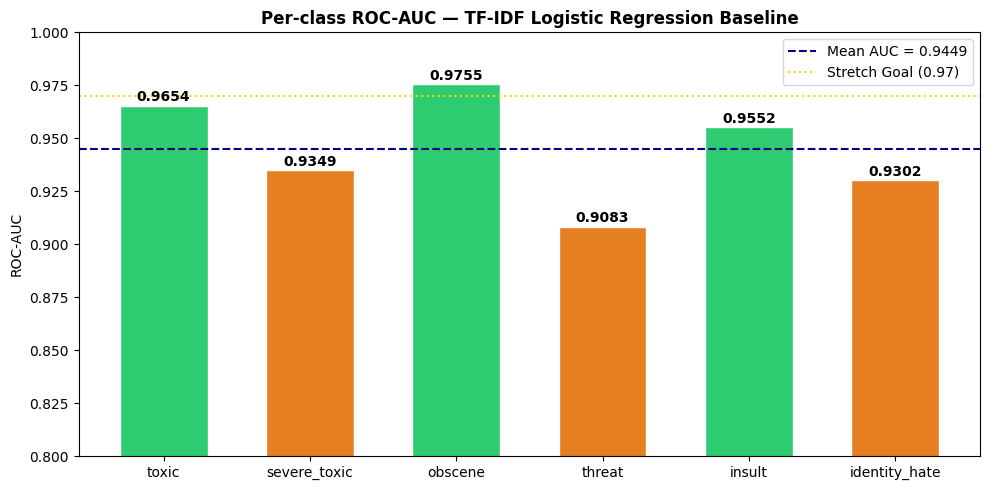

In [19]:
# ── Cell 13: AUC Bar Chart ────────────────────────────────────────────────
plot_df = results_df[results_df['Label'] != 'MEAN']

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if v >= 0.95 else '#e67e22' if v >= 0.90 else '#e74c3c'
          for v in plot_df['ROC-AUC']]
bars = ax.bar(plot_df['Label'], plot_df['ROC-AUC'], color=colors, edgecolor='white', width=0.6)
ax.axhline(mean_auc, color='navy', linestyle='--', label=f'Mean AUC = {mean_auc:.4f}')
ax.axhline(0.97, color='gold', linestyle=':', label='Stretch Goal (0.97)')
ax.set_ylim(0.80, 1.0)
ax.set_ylabel('ROC-AUC')
ax.set_title('Per-class ROC-AUC — TF-IDF Logistic Regression Baseline',
             fontweight='bold')
for bar, val in zip(bars, plot_df['ROC-AUC']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
# ── Cell 14: Generate Submission File ────────────────────────────────────
test_preds = np.zeros((X_test.shape[0], len(LABELS)))

for i, label in enumerate(LABELS):
    test_preds[:, i] = models[label].predict_proba(X_test)[:, 1]

submission = pd.DataFrame({'id': test['id']})
for i, label in enumerate(LABELS):
    submission[label] = test_preds[:, i]

submission.to_csv('submission_baseline.csv', index=False)
print('✅ submission_baseline.csv saved!')
submission.head()

✅ submission_baseline.csv saved!


,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,a9157bae71e0e640,0.015219,2.189092e-08,0.011411,1.981727e-13,0.023271,1.605034e-09
1,6f60af95fa052a2b,0.070316,3.162277e-04,0.026900,6.027753e-11,0.019901,1.797555e-04
2,1b9e3187dacf2e47,0.005770,2.405143e-07,0.007338,3.294666e-20,0.002195,6.015707e-11
3,8205cbbf498809d8,0.999608,9.774910e-01,0.858467,1.000000e+00,0.984383,9.999875e-01
4,4066b6781527c3ef,0.021778,2.073475e-06,0.012538,1.707987e-15,0.036010,1.516012e-01
